# Data Preprocessing for Modeling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import r2_score as R2
from sklearn.model_selection import RandomizedSearchCV, KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import logging
import warnings
import sys
import os
from google.colab import drive

drive.mount('/content/drive')
os.environ['PYTHONUNBUFFERED'] = '1'

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

Mounted at /content/drive


In [2]:
df = pd.read_csv("/content/drive/MyDrive/PJM_Energy_Consumption_Preprocessed.csv")
df.head(10)

,Datetime,Energy_Consumption,Company,Hour,Year,Month,WeekDay,Day,Lag_1,Lag_2,Lag_3,Lag_24,Lag_168,Rolling_mean_24,Rolling_std_24,Exp_Moving_Avg_24
0,2004-05-08 01:00:00,9132.0,Comed,1,2004,5,5,8,9930.0,10632.0,10903.0,9532.0,9198.0,10097.208333,1154.601493,10548.453684
1,2004-05-08 02:00:00,8476.0,Comed,2,2004,5,5,8,9132.0,9930.0,10632.0,8812.0,8570.0,10083.208333,1172.757026,10435.137389
2,2004-05-08 03:00:00,8090.0,Comed,3,2004,5,5,8,8476.0,9132.0,9930.0,8389.0,8183.0,10070.750000,1192.951592,10278.406398
3,2004-05-08 04:00:00,7876.0,Comed,4,2004,5,5,8,8090.0,8476.0,9132.0,8118.0,7917.0,10060.666667,1211.059998,10103.333886
4,2004-05-08 05:00:00,7753.0,Comed,5,2004,5,5,8,7876.0,8090.0,8476.0,7984.0,7828.0,10051.041667,1229.066152,9925.147175
5,2004-05-08 06:00:00,7691.0,Comed,6,2004,5,5,8,7753.0,7876.0,8090.0,8125.0,7806.0,10032.958333,1261.403548,9751.375401
6,2004-05-08 07:00:00,7891.0,Comed,7,2004,5,5,8,7691.0,7753.0,7876.0,8701.0,8082.0,9999.208333,1308.545990,9586.545369
7,2004-05-08 08:00:00,8091.0,Comed,8,2004,5,5,8,7891.0,7691.0,7753.0,9774.0,8267.0,9929.083333,1365.017118,9450.901740
8,2004-05-08 09:00:00,8634.0,Comed,9,2004,5,5,8,8091.0,7891.0,7691.0,10776.0,8830.0,9839.833333,1377.206519,9342.109600
9,2004-05-08 10:00:00,9166.0,Comed,10,2004,5,5,8,8634.0,8091.0,7891.0,11120.0,9381.0,9758.416667,1355.827773,9285.460832


In [3]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767355 entries, 0 to 767354
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Datetime            767355 non-null  datetime64[ns]
 1   Energy_Consumption  767355 non-null  float64       
 2   Company             767355 non-null  object        
 3   Hour                767355 non-null  int64         
 4   Year                767355 non-null  int64         
 5   Month               767355 non-null  int64         
 6   WeekDay             767355 non-null  int64         
 7   Day                 767355 non-null  int64         
 8   Lag_1               767355 non-null  float64       
 9   Lag_2               767355 non-null  float64       
 10  Lag_3               767355 non-null  float64       
 11  Lag_24              767355 non-null  float64       
 12  Lag_168             767355 non-null  float64       
 13  Rolling_mean_24     767355 no

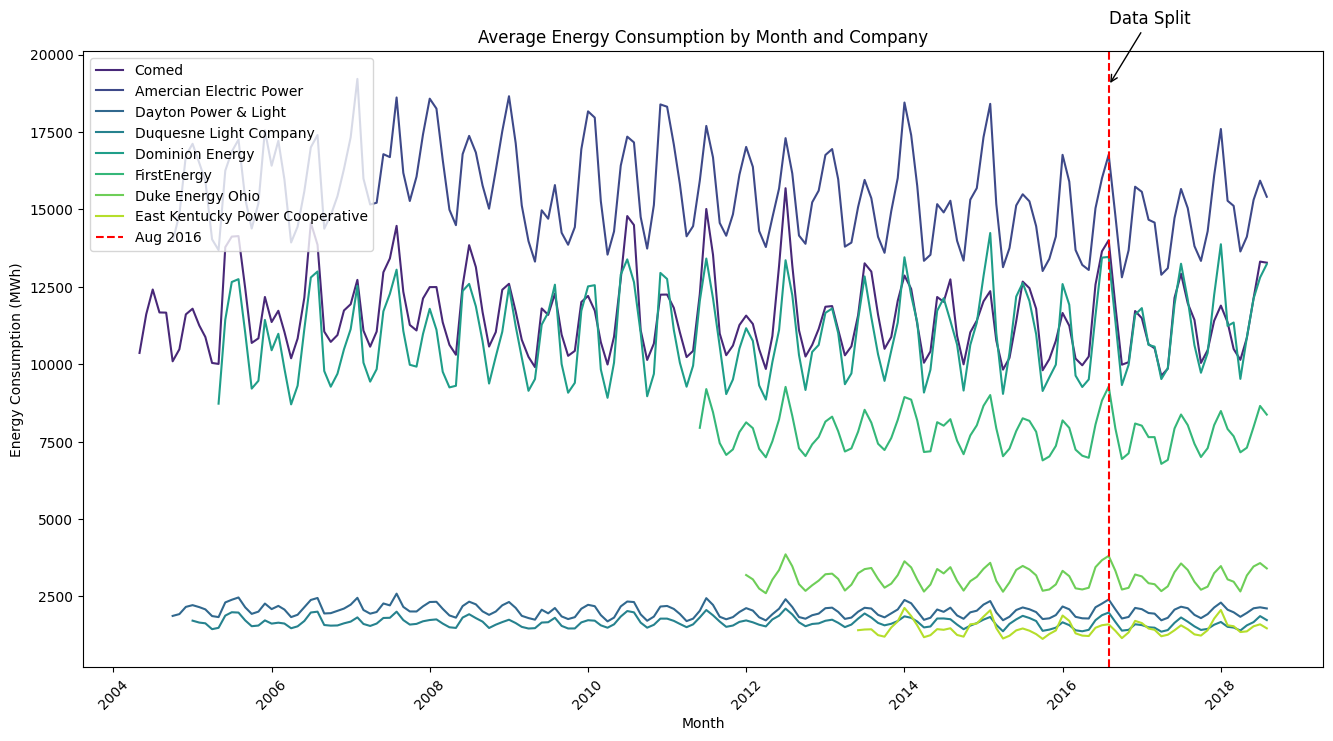

In [4]:
def plot_energy_consumption(df, title):
    fig, ax = plt.subplots(figsize=(16, 8))
    grouped_data = df.groupby([
        df["Datetime"].dt.to_period("M"),
        "Company"
    ])["Energy_Consumption"].mean()

    x_vals = grouped_data.index.get_level_values(0).to_timestamp()

    sns.lineplot(
        x=x_vals,
        y=grouped_data,
        hue=grouped_data.index.get_level_values(1),
        palette='viridis',
        ax=ax
    )

    split_date = pd.to_datetime("2016-08-01")
    ax.axvline(split_date, color='red', linestyle='--', label='Aug 2016')
    ax.annotate(
        "Data Split",
        xy=(split_date, 19000),
        xytext=(split_date, 21000),
        arrowprops=dict(facecolor='black', arrowstyle="->"),
        fontsize=12,
        color='black'
    )
    ax.legend(fontsize=10, loc='upper left', bbox_to_anchor=(0, 1))

    plt.xticks(rotation=45)
    plt.xlabel("Month")
    plt.ylabel("Energy Consumption (MWh)")
    plt.title(title)
    plt.show()

plot_energy_consumption(df, "Average Energy Consumption by Month and Company")

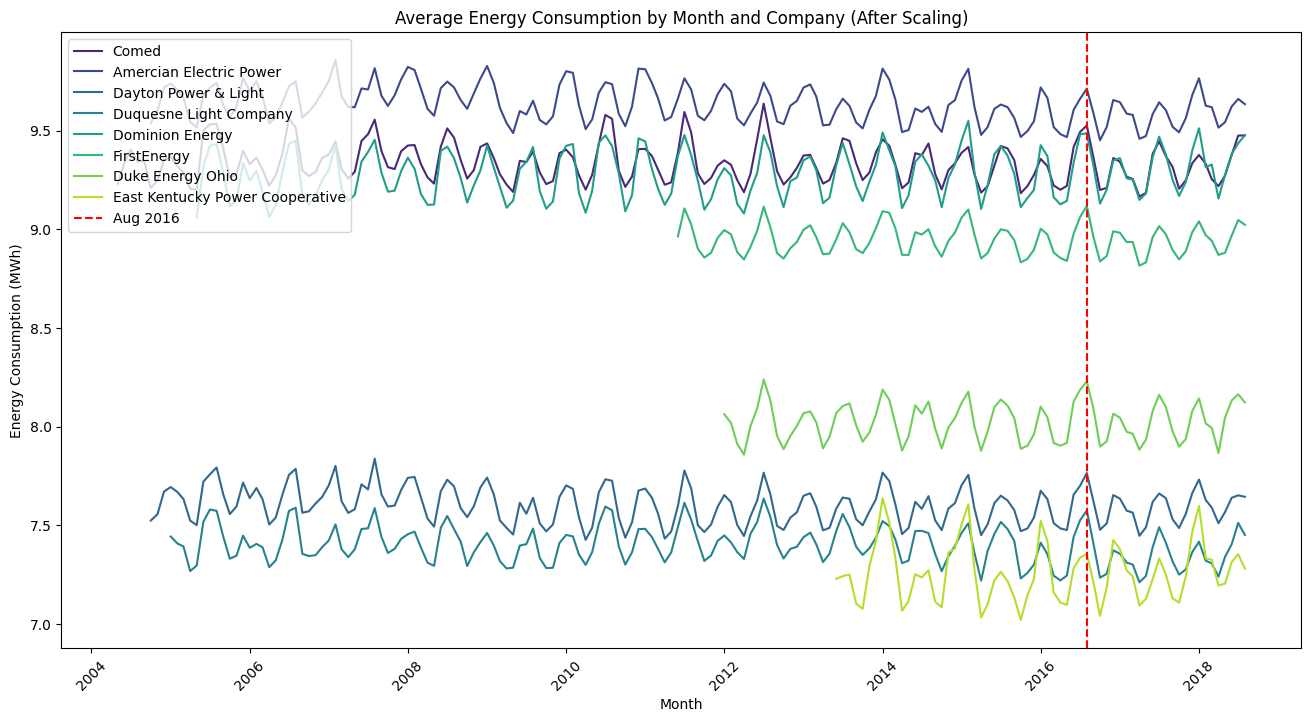

In [5]:
df_transformed = df.copy()
df_transformed["Energy_Consumption"] = np.log(df_transformed["Energy_Consumption"])
plot_energy_consumption(df_transformed, "Average Energy Consumption by Month and Company (After Scaling)")

In [6]:
df_transformed["Datetime"].max()

Timestamp('2018-08-03 00:00:00')

In [7]:
df_transformed = pd.get_dummies(df_transformed, columns=["Company"])
df_transformed.head()

,Datetime,Energy_Consumption,Hour,Year,Month,WeekDay,Day,Lag_1,Lag_2,Lag_3,Lag_24,Lag_168,Rolling_mean_24,Rolling_std_24,Exp_Moving_Avg_24,Company_Amercian Electric Power,Company_Comed,Company_Dayton Power & Light,Company_Dominion Energy,Company_Duke Energy Ohio,Company_Duquesne Light Company,Company_East Kentucky Power Cooperative,Company_FirstEnergy
0,2004-05-08 01:00:00,9.119540,1,2004,5,5,8,9930.0,10632.0,10903.0,9532.0,9198.0,10097.208333,1154.601493,10548.453684,False,True,False,False,False,False,False,False
1,2004-05-08 02:00:00,9.044994,2,2004,5,5,8,9132.0,9930.0,10632.0,8812.0,8570.0,10083.208333,1172.757026,10435.137389,False,True,False,False,False,False,False,False
2,2004-05-08 03:00:00,8.998384,3,2004,5,5,8,8476.0,9132.0,9930.0,8389.0,8183.0,10070.750000,1192.951592,10278.406398,False,True,False,False,False,False,False,False
3,2004-05-08 04:00:00,8.971575,4,2004,5,5,8,8090.0,8476.0,9132.0,8118.0,7917.0,10060.666667,1211.059998,10103.333886,False,True,False,False,False,False,False,False
4,2004-05-08 05:00:00,8.955835,5,2004,5,5,8,7876.0,8090.0,8476.0,7984.0,7828.0,10051.041667,1229.066152,9925.147175,False,True,False,False,False,False,False,False


In [8]:
split_date = pd.to_datetime("2016-08-01")

test = df_transformed[df_transformed["Datetime"] >= split_date]
train = df_transformed[df_transformed["Datetime"] < split_date]

In [9]:
print(f"Data has been split into:\n{round((len(train)/len(df_transformed))*100,2)}% Train\n{round((len(test)/len(df_transformed))*100,2)}%Test")

Data has been split into:
81.68% Train
18.32%Test


In [10]:
X_train = train.drop(columns=["Energy_Consumption", "Datetime"])
y_train = train["Energy_Consumption"]
X_test = test.drop(columns=["Energy_Consumption", "Datetime"])
y_test = test["Energy_Consumption"]

In [11]:
len(X_train.columns)

21

# Training XGBoost Model

In [12]:
model = XGBRegressor(
    random_state=42,
    verbosity=2,
    n_jobs=1  # ← Fix this
)

In [13]:
parameters = {
    "n_estimators": [100, 200],
    "max_depth": [4,6,8],
    "learning_rate": [0.01,0.1,0.2],
    "subsample": [0.8,0.9,1],
    "colsample_bytree": [0.7,0.8]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=parameters,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=3,
    n_jobs=1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[19:31:53] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (417868, 21, 8775228).
[CV 1/3] END colsample_bytree=0.8, learning_rate=0.1, max_depth=4, n_estimators=200, subsample=1;, score=-0.000 total time=   9.2s
[19:32:03] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (417869, 21, 8775249).
[CV 2/3] END colsample_bytree=0.8, learning_rate=0.1, max_depth=4, n_estimators=200, subsample=1;, score=-0.000 total time=   8.2s
[19:32:11] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (417869, 21, 8775249).
[CV 3/3] END colsample_bytree=0.8, learning_rate=0.1, max_depth=4, n_estimators=200, subsample=1;, score=-0.001 total time=   9.0s
[19:32:20] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (417

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=1,
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=1,
                   param_distributions={'colsample_bytree': [0.7, 0.8],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [4, 6, 8],
                                        'n_estimators': [100, 200],
                                        'subsample': [0.8, 0.9, 1]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=3)

In [15]:
model = random_search.best_estimator_
model.fit(X_train, y_train)

[20:00:54] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (626803, 21, 13162863).


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=1, num_parallel_tree=None, ...)

In [16]:
y_pred = model.predict(X_test)
mse = MSE(y_test, y_pred)
r2 = R2(y_test, y_pred)
print(f"MSE: {mse}\nR2: {r2}")

MSE: 0.00027028899812799837
R2: 0.9996835680266996


In [17]:
company_cols = [col for col in df_transformed.columns if col.startswith("Company_")]

df_transformed["Company"] = df_transformed[company_cols].idxmax(axis=1).str.replace("Company_", "")

In [18]:
plot_df = X_test.copy()
plot_df["Actual"] = y_test
plot_df["Predicted"] = y_pred

In [19]:
company_cols = [col for col in plot_df.columns if col.startswith("Company_")]
plot_df["Company"] = plot_df[company_cols].idxmax(axis=1).str.replace("Company_", "")

plot_df["Datetime"] = pd.to_datetime(dict(
    year=plot_df["Year"],
    month=plot_df["Month"],
    day=plot_df["Day"]
))

In [20]:
grouped_actual = plot_df.groupby([plot_df["Datetime"].dt.to_period("M"), "Company"])["Actual"].mean()
grouped_pred = plot_df.groupby([plot_df["Datetime"].dt.to_period("M"), "Company"])["Predicted"].mean()

plot_grouped = pd.DataFrame({
    "Actual": grouped_actual,
    "Predicted": grouped_pred
}).reset_index()

plot_grouped["Month"] = plot_grouped["Datetime"].dt.to_timestamp()

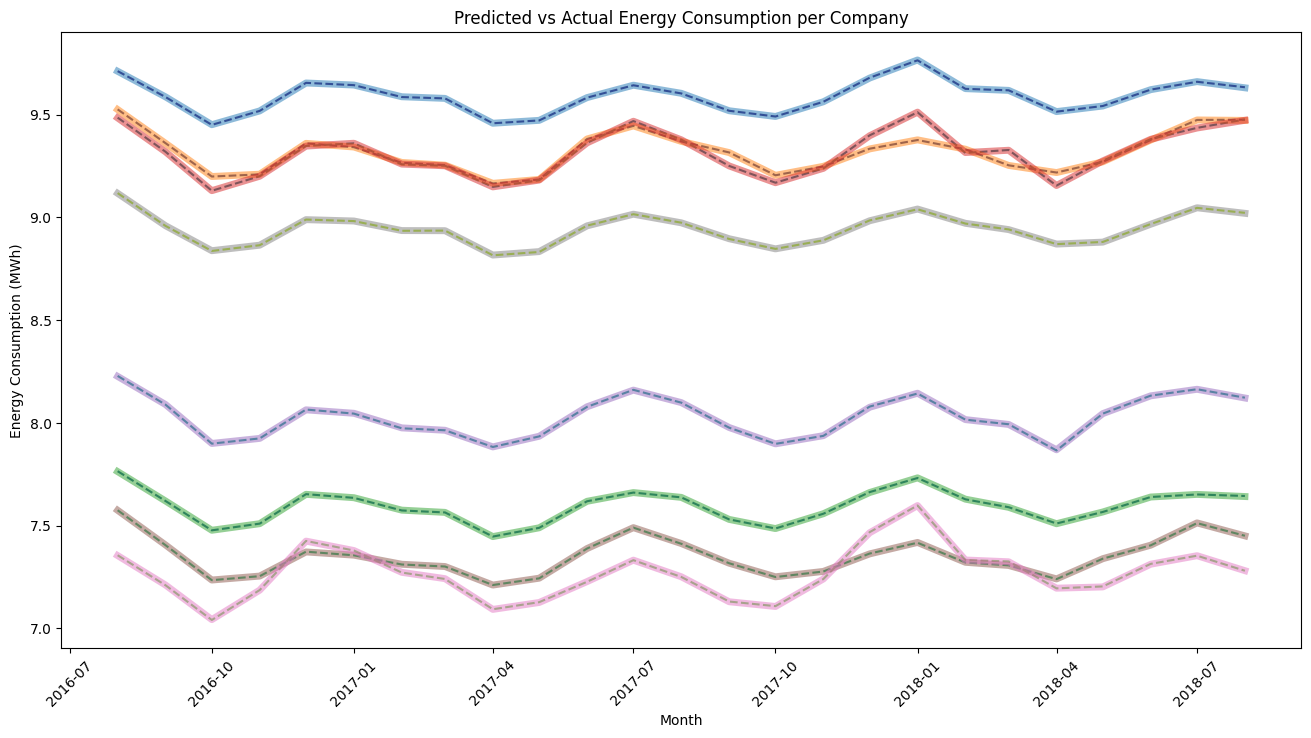

In [24]:
fig, ax = plt.subplots(figsize=(16, 8))

# Actual Values Plot:
sns.lineplot(
    data=plot_grouped,
    x="Month",
    y="Actual",
    hue="Company",
    palette="viridis",
    ax=ax,
    linestyle="--",
    legend=False
)

# Predicted Values Plot:
sns.lineplot(
    data=plot_grouped,
    x="Month",
    y="Predicted",
    hue="Company",
    ax=ax,
    color="red",
    linewidth=5,
    alpha=0.5,
    legend=False
)


ax.set_xlabel("Month")
ax.set_ylabel("Energy Consumption (MWh)")
ax.set_title("Predicted vs Actual Energy Consumption per Company")
plt.xticks(rotation=45)
plt.show()

In [22]:
import joblib

model_path = '/content/drive/MyDrive/energy_consumption_model.pkl'

joblib.dump(model, model_path)

print(f"Model saved to {model_path}")

Model saved to /content/drive/MyDrive/energy_consumption_model.pkl
